# Analyse géospatiale et priorisation des navires détectés

Ce notebook recentre le projet sur la vraie base de travail du sujet 5 : les fichiers fournis dans `Sujet5/Généralisation`.

Idée clé : on ne refait pas la computer vision ici. On exploite ses résultats.

In [1]:
from pathlib import Path
import json
import math

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('.')
if not (DATA_DIR / 'images_metadata_large.csv').exists():
    DATA_DIR = Path('Sujet5/Généralisation')

images = pd.read_csv(DATA_DIR / 'images_metadata_large.csv')
detections = pd.read_csv(DATA_DIR / 'detection_results.csv')
zones = pd.read_csv(DATA_DIR / 'military_zones.csv')

print('Images metadata:', images.shape)
print('Detections:', detections.shape)
print('Military zones:', zones.shape)

images.head()

Images metadata: (100, 15)
Detections: (256, 11)
Military zones: (20, 8)


,image_id,file_name,date,time,zone_id,zone_name,coordinates,country,risk_level,resolution,source,num_ships,ship_types,cloud_cover,url
0,IMG-000,satellite_000.jpg,2026-08-31,17:17:58,ZONE-002,Base navale de Norfolk,"36.9,-76.3",USA,High,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,https://example.com/satellite_images/satellite...
1,IMG-001,satellite_001.jpg,2026-04-17,04:54:56,ZONE-002,Base navale de Norfolk,"36.9,-76.3",USA,High,10m,Maxar,2,"Destroyer, Navire de guerre",39.0,https://example.com/satellite_images/satellite...
2,IMG-002,satellite_002.jpg,2026-03-02,15:20:53,ZONE-009,Base navale de Yokosuka,"35.4,139.7",Japan,High,1m,Sentinel-2,4,"Navire de soutien, Chalutier, Porte-avions, Na...",25.6,https://example.com/satellite_images/satellite...
3,IMG-003,satellite_003.jpg,2026-08-17,16:27:15,ZONE-012,Détroit d'Ormuz,"25.0,56.0",International,Critical,0.5m,PlanetScope,0,Aucun,27.3,https://example.com/satellite_images/satellite...
4,IMG-004,satellite_004.jpg,2026-10-03,08:53:49,ZONE-015,Mer Baltique,"55.0,20.0",International,Medium,1m,Sentinel-2,3,"Destroyer, Pétrolier, Frégate",32.7,https://example.com/satellite_images/satellite...


## 1. Compréhension des fichiers

`images_metadata_large.csv` décrit les images ou zones observées.

`detection_results.csv` représente une sortie de computer vision : une ligne par objet détecté.

`military_zones.csv` décrit des zones militaires ou sensibles, avec un niveau de risque et un statut actif/inactif.

Les URLs d'images sont factices, mais ce n'est pas bloquant pour cette étape : on travaille sur les résultats de détection déjà fournis.

In [2]:
print('Colonnes images:')
print(images.columns.tolist())
print()
print('Colonnes detections:')
print(detections.columns.tolist())
print()
print('Colonnes zones:')
print(zones.columns.tolist())

Colonnes images:
['image_id', 'file_name', 'date', 'time', 'zone_id', 'zone_name', 'coordinates', 'country', 'risk_level', 'resolution', 'source', 'num_ships', 'ship_types', 'cloud_cover', 'url']

Colonnes detections:
['detection_id', 'image_id', 'file_name', 'timestamp', 'bbox', 'category', 'confidence', 'is_military', 'zone_id', 'zone_name', 'risk_level']

Colonnes zones:
['zone_id', 'name', 'coordinates', 'country', 'risk_level', 'description', 'base_name', 'active']


## 2. Parsing des coordonnées

Les coordonnées sont stockées sous forme texte : `latitude,longitude`.

On les convertit en colonnes numériques pour pouvoir cartographier et calculer des distances.

In [3]:
def split_coordinates(value):
    lat, lon = str(value).split(',')
    return float(lat.strip()), float(lon.strip())

images[['latitude', 'longitude']] = images['coordinates'].apply(lambda x: pd.Series(split_coordinates(x)))
zones[['zone_latitude', 'zone_longitude']] = zones['coordinates'].apply(lambda x: pd.Series(split_coordinates(x)))

images[['image_id', 'zone_name', 'country', 'risk_level', 'latitude', 'longitude']].head()

,image_id,zone_name,country,risk_level,latitude,longitude
0,IMG-000,Base navale de Norfolk,USA,High,36.9,-76.3
1,IMG-001,Base navale de Norfolk,USA,High,36.9,-76.3
2,IMG-002,Base navale de Yokosuka,Japan,High,35.4,139.7
3,IMG-003,Détroit d'Ormuz,International,Critical,25.0,56.0
4,IMG-004,Mer Baltique,International,Medium,55.0,20.0


## 3. Enrichissement des détections

Les détections n'ont pas de coordonnées GPS individuelles. Elles ont une bounding box dans l'image et une zone.

On les rattache donc aux coordonnées de l'image ou de la zone observée. La carte représente des observations par zone, pas la position exacte du navire au mètre près.

In [4]:
image_context = images[[
    'image_id', 'date', 'time', 'coordinates', 'country', 'resolution', 'source',
    'num_ships', 'ship_types', 'cloud_cover', 'latitude', 'longitude'
]].copy()

enriched = detections.merge(image_context, on='image_id', how='left')
enriched['is_military'] = enriched['is_military'].astype(str).str.lower().eq('true')

enriched.head()

,detection_id,image_id,file_name,timestamp,bbox,category,confidence,is_military,zone_id,zone_name,...,time,coordinates,country,resolution,source,num_ships,ship_types,cloud_cover,latitude,longitude
0,DET-000-00001,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.3766847153545144,0.602830810224785,0.2798675...",Navire de guerre,0.84,True,ZONE-002,Base navale de Norfolk,...,17:17:58,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,36.9,-76.3
1,DET-000-00002,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.6730405409693083,0.37685587994514613,0.29411...",Navire civil,0.72,False,ZONE-002,Base navale de Norfolk,...,17:17:58,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,36.9,-76.3
2,DET-000-00003,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.3499607760017571,0.6063398574692226,0.244706...",Bâtiment de débarquement,0.96,False,ZONE-002,Base navale de Norfolk,...,17:17:58,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,36.9,-76.3
3,DET-000-00004,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.6159782694606443,0.45954657746946426,0.27517...",Destroyer,0.89,True,ZONE-002,Base navale de Norfolk,...,17:17:58,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,36.9,-76.3
4,DET-000-00005,IMG-000,satellite_000.jpg,2026-08-31T17:17:58Z,"0.7200515440830189,0.2160546184846373,0.135625...",Pétrolier,0.90,False,ZONE-002,Base navale de Norfolk,...,17:17:58,"36.9,-76.3",USA,1m,Sentinel-2,5,"Navire de guerre, Navire civil, Bâtiment de dé...",17.0,36.9,-76.3


## 4. Distance à la zone militaire la plus proche

Les IDs `MIL-*` et `ZONE-*` ne correspondent pas directement. On utilise donc une distance géographique simple pour rattacher chaque observation à la zone militaire la plus proche.

In [12]:
def haversine_km(lat1, lon1, lat2, lon2):
    radius = 6371
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * radius * math.asin(math.sqrt(a))

zone_records = zones.to_dict('records')

def nearest_military_zone(row):
    distances = []
    for zone in zone_records:
        distance = haversine_km(row['latitude'], row['longitude'], zone['zone_latitude'], zone['zone_longitude'])
        distances.append((distance, zone))
    distance, zone = min(distances, key=lambda item: item[0])
    return pd.Series({
        'nearest_military_zone': zone['name'],
        'nearest_military_zone_distance_km': distance,
        'nearest_military_zone_active': bool(zone['active']),
        'nearest_military_zone_risk': zone['risk_level'],
    })

enriched = pd.concat([enriched, enriched.apply(nearest_military_zone, axis=1)], axis=1)

enriched[['detection_id', 'category', 'zone_name', 'risk_level', 'nearest_military_zone', 'nearest_military_zone_distance_km', 'nearest_military_zone_active']]

,detection_id,category,zone_name,risk_level,nearest_military_zone,nearest_military_zone,nearest_military_zone_distance_km,nearest_military_zone_distance_km,nearest_military_zone_active,nearest_military_zone_active
0,DET-000-00001,Navire de guerre,Base navale de Norfolk,High,Zone militaire 15 - Base navale de Rota,Zone militaire 15 - Base navale de Rota,6076.446076,6076.446076,False,False
1,DET-000-00002,Navire civil,Base navale de Norfolk,High,Zone militaire 15 - Base navale de Rota,Zone militaire 15 - Base navale de Rota,6076.446076,6076.446076,False,False
2,DET-000-00003,Bâtiment de débarquement,Base navale de Norfolk,High,Zone militaire 15 - Base navale de Rota,Zone militaire 15 - Base navale de Rota,6076.446076,6076.446076,False,False
3,DET-000-00004,Destroyer,Base navale de Norfolk,High,Zone militaire 15 - Base navale de Rota,Zone militaire 15 - Base navale de Rota,6076.446076,6076.446076,False,False
4,DET-000-00005,Pétrolier,Base navale de Norfolk,High,Zone militaire 15 - Base navale de Rota,Zone militaire 15 - Base navale de Rota,6076.446076,6076.446076,False,False
...,...,...,...,...,...,...,...,...,...,...
251,DET-099-00252,Navire de soutien,Mer de Chine Méridionale,Critical,Zone militaire 16 - Détroit de Malacca,Zone militaire 16 - Détroit de Malacca,1659.387447,1659.387447,False,False
252,DET-099-00253,Cargo,Mer de Chine Méridionale,Critical,Zone militaire 16 - Détroit de Malacca,Zone militaire 16 - Détroit de Malacca,1659.387447,1659.387447,False,False
253,DET-099-00254,Corvette,Mer de Chine Méridionale,Critical,Zone militaire 16 - Détroit de Malacca,Zone militaire 16 - Détroit de Malacca,1659.387447,1659.387447,False,False
254,DET-099-00255,Bâtiment de débarquement,Mer de Chine Méridionale,Critical,Zone militaire 16 - Détroit de Malacca,Zone militaire 16 - Détroit de Malacca,1659.387447,1659.387447,False,False


## 5. Score de priorité

Le score sert à trier les détections pour un analyste. Il ne prétend pas mesurer une menace réelle : il rend simplement la règle de priorisation explicite.

In [6]:
strategic_types = {'Porte-avions', 'Sous-marin', 'Destroyer', 'Croiseur'}
risk_points = {'Critical': 25, 'High': 15, 'Medium': 5, 'Low': 0}

def compute_priority(row):
    score = 0
    if row['is_military']:
        score += 40
    score += risk_points.get(row['risk_level'], 0)
    if row['confidence'] >= 0.85:
        score += 15
    elif row['confidence'] >= 0.75:
        score += 8
    if row['category'] in strategic_types:
        score += 20
    if row['nearest_military_zone_active'] and row['nearest_military_zone_distance_km'] <= 25:
        score += 10
    return score

enriched['priority_score'] = enriched.apply(compute_priority, axis=1)
enriched['priority_level'] = pd.cut(
    enriched['priority_score'],
    bins=[-1, 39, 69, 89, 200],
    labels=['Low', 'Medium', 'High', 'Critical']
)

top_detections = enriched.sort_values('priority_score', ascending=False)
top_detections[['detection_id', 'image_id', 'category', 'confidence', 'is_military', 'zone_name', 'risk_level', 'nearest_military_zone_distance_km', 'priority_score', 'priority_level']].head(15)

,detection_id,image_id,category,confidence,is_military,zone_name,risk_level,nearest_military_zone_distance_km,priority_score,priority_level
78,DET-024-00079,IMG-024,Destroyer,0.94,True,Détroit d'Ormuz,Critical,0.000000,110,Critical
76,DET-024-00077,IMG-024,Porte-avions,0.78,True,Détroit d'Ormuz,Critical,0.000000,103,Critical
135,DET-049-00136,IMG-049,Croiseur,0.82,True,Détroit d'Ormuz,Critical,0.000000,103,Critical
134,DET-049-00135,IMG-049,Destroyer,0.79,True,Détroit d'Ormuz,Critical,0.000000,103,Critical
28,DET-008-00029,IMG-008,Porte-avions,0.76,True,Détroit d'Ormuz,Critical,0.000000,103,Critical
108,DET-034-00109,IMG-034,Porte-avions,0.92,True,Mer de Chine Méridionale,Critical,1659.387447,100,Critical
220,DET-086-00221,IMG-086,Croiseur,0.89,True,Détroit de Malacca,Critical,0.000000,100,Critical
155,DET-055-00156,IMG-055,Sous-marin,0.93,True,Détroit de Malacca,Critical,0.000000,100,Critical
154,DET-055-00155,IMG-055,Porte-avions,0.98,True,Détroit de Malacca,Critical,0.000000,100,Critical
49,DET-014-00050,IMG-014,Destroyer,0.87,True,Golfe Persique,Critical,0.000000,100,Critical


## 6. Résumé par zone

Cette table permet de repérer rapidement les zones avec beaucoup de détections militaires ou des scores élevés.

In [7]:
summary_by_zone = enriched.groupby(['zone_name', 'risk_level']).agg(
    detections=('detection_id', 'count'),
    military_detections=('is_military', 'sum'),
    avg_confidence=('confidence', 'mean'),
    max_priority=('priority_score', 'max'),
    avg_priority=('priority_score', 'mean'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first'),
).reset_index().sort_values(['max_priority', 'military_detections'], ascending=False)

summary_by_zone.head(15)

,zone_name,risk_level,detections,military_detections,avg_confidence,max_priority,avg_priority,latitude,longitude
5,Détroit d'Ormuz,Critical,10,6,0.842000,110,79.700000,25.00,56.0
6,Détroit de Malacca,Critical,38,22,0.848947,100,64.052632,3.00,101.0
9,Mer de Chine Méridionale,Critical,30,14,0.887333,100,62.800000,15.00,110.0
7,Golfe Persique,Critical,5,3,0.874000,100,65.000000,26.00,55.0
1,Base navale de Pearl Harbor,High,6,3,0.818333,93,60.666667,21.40,-157.9
0,Base navale de Norfolk,High,26,18,0.867692,90,62.538462,36.90,-76.3
2,Base navale de Rota,High,21,10,0.838571,90,47.333333,36.60,-6.4
14,Port militaire de Toulon,High,10,7,0.856000,90,61.700000,43.12,5.9
12,Port de Shanghai,Medium,18,6,0.833889,90,40.000000,31.20,121.5
3,Base navale de Yokosuka,High,12,4,0.873333,83,42.000000,35.40,139.7


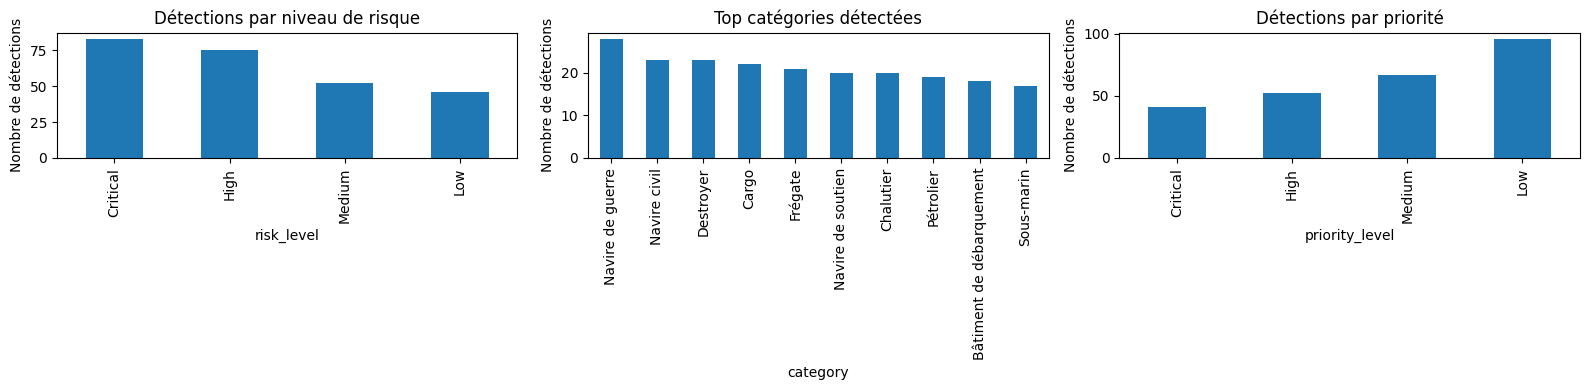

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

enriched['risk_level'].value_counts().reindex(['Critical', 'High', 'Medium', 'Low']).plot(kind='bar', ax=axes[0], title='Détections par niveau de risque')
axes[0].set_ylabel('Nombre de détections')

enriched['category'].value_counts().head(10).plot(kind='bar', ax=axes[1], title='Top catégories détectées')
axes[1].set_ylabel('Nombre de détections')

enriched['priority_level'].value_counts().reindex(['Critical', 'High', 'Medium', 'Low']).plot(kind='bar', ax=axes[2], title='Détections par priorité')
axes[2].set_ylabel('Nombre de détections')

plt.tight_layout()
plt.show()

## 7. Visualisation géographique simple

Sans `geopandas` ni `folium`, on peut déjà faire une carte de points en latitude / longitude.

Ce n'est pas une carte marine complète, mais elle permet de voir la distribution mondiale des observations et les zones prioritaires.

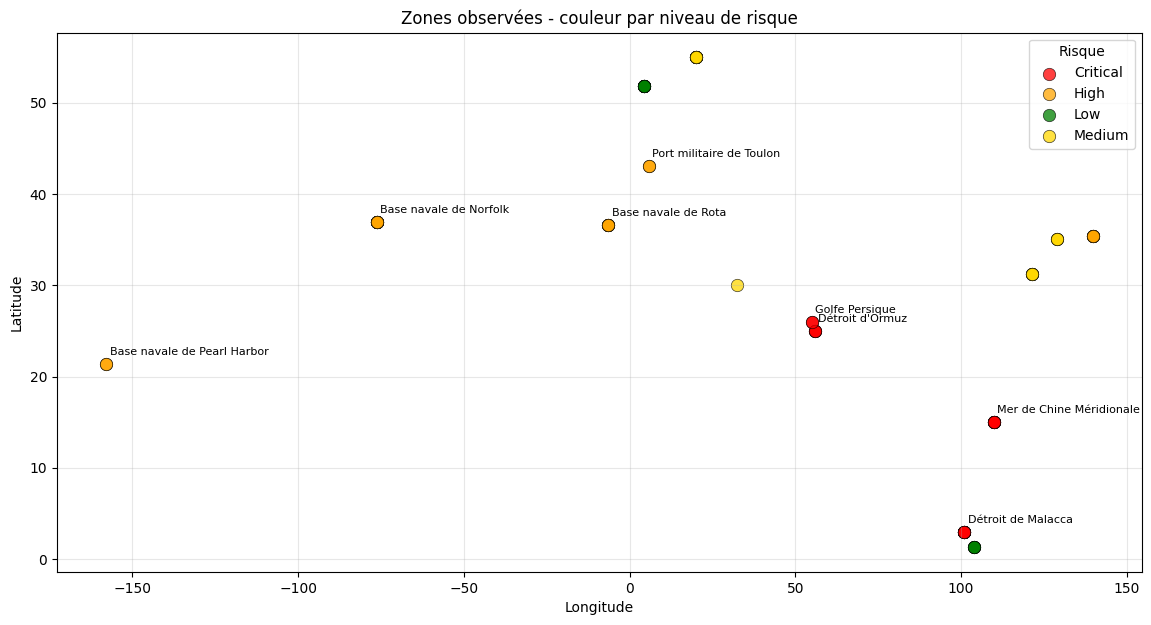

In [9]:
plot_data = enriched.drop_duplicates('image_id').copy()
color_map = {'Critical': 'red', 'High': 'orange', 'Medium': 'gold', 'Low': 'green'}

fig, ax = plt.subplots(figsize=(14, 7))
for risk, group in plot_data.groupby('risk_level'):
    ax.scatter(group['longitude'], group['latitude'], s=80, alpha=0.75, label=risk, c=color_map.get(risk, 'gray'), edgecolors='black', linewidths=0.5)

for _, row in summary_by_zone.head(8).iterrows():
    ax.text(row['longitude'] + 1, row['latitude'] + 1, row['zone_name'], fontsize=8)

ax.set_title('Zones observées - couleur par niveau de risque')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
ax.legend(title='Risque')
plt.show()

## 8. Carte HTML interactive

On génère un fichier HTML avec Leaflet, sans dépendre de `folium`. Le fichier produit est `carte_priorisation_navires.html`.

La carte utilise OpenStreetMap via internet au moment de l'ouverture dans le navigateur.

In [10]:
def marker_color(priority):
    if priority == 'Critical':
        return 'red'
    if priority == 'High':
        return 'orange'
    if priority == 'Medium':
        return 'gold'
    return 'green'

zone_payload = []
for _, row in summary_by_zone.iterrows():
    zone_payload.append({
        'zone_name': row['zone_name'],
        'risk_level': row['risk_level'],
        'lat': float(row['latitude']),
        'lon': float(row['longitude']),
        'detections': int(row['detections']),
        'military_detections': int(row['military_detections']),
        'max_priority': float(row['max_priority']),
    })

detection_payload = []
for _, row in enriched.sort_values('priority_score', ascending=False).head(80).iterrows():
    detection_payload.append({
        'detection_id': row['detection_id'],
        'category': row['category'],
        'confidence': float(row['confidence']),
        'is_military': bool(row['is_military']),
        'zone_name': row['zone_name'],
        'risk_level': row['risk_level'],
        'lat': float(row['latitude']),
        'lon': float(row['longitude']),
        'priority_score': int(row['priority_score']),
        'priority_level': str(row['priority_level']),
        'color': marker_color(str(row['priority_level'])),
    })

leaflet_css = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.css'
leaflet_js = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.js'
html = f'''<!DOCTYPE html>
<html>
<head>
  <meta charset="utf-8" />
  <title>Priorisation des navires détectés</title>
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <link rel="stylesheet" href="{leaflet_css}" />
  <style>
    body {{ margin: 0; font-family: Arial, sans-serif; }}
    #map {{ height: 100vh; width: 100vw; }}
    .legend {{ background: white; padding: 10px; line-height: 1.4; border-radius: 4px; box-shadow: 0 1px 4px rgba(0,0,0,0.3); }}
  </style>
</head>
<body>
<div id="map"></div>
<script src="{leaflet_js}"></script>
<script>
const detections = {json.dumps(detection_payload, ensure_ascii=False)};
const zones = {json.dumps(zone_payload, ensure_ascii=False)};

const map = L.map('map').setView([25, 30], 2);
L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
  maxZoom: 8,
  attribution: '&copy; OpenStreetMap contributors'
}}).addTo(map);

zones.forEach(z => {{
  L.circle([z.lat, z.lon], {{
    radius: 55000,
    color: 'blue',
    fillColor: 'blue',
    fillOpacity: 0.08,
    weight: 1
  }}).bindPopup(`<b>${{z.zone_name}}</b><br>Risque: ${{z.risk_level}}<br>Détections: ${{z.detections}}<br>Militaires: ${{z.military_detections}}<br>Score max: ${{z.max_priority}}`).addTo(map);
}});

detections.forEach(d => {{
  L.circleMarker([d.lat, d.lon], {{
    radius: Math.max(5, Math.min(14, d.priority_score / 8)),
    color: d.color,
    fillColor: d.color,
    fillOpacity: 0.75,
    weight: 1
  }}).bindPopup(`<b>${{d.category}}</b><br>ID: ${{d.detection_id}}<br>Zone: ${{d.zone_name}}<br>Risque: ${{d.risk_level}}<br>Militaire: ${{d.is_military}}<br>Confiance: ${{d.confidence}}<br>Score: ${{d.priority_score}} (${{d.priority_level}})`).addTo(map);
}});

const legend = L.control({{position: 'bottomright'}});
legend.onAdd = function () {{
  const div = L.DomUtil.create('div', 'legend');
  div.innerHTML = '<b>Priorité</b><br><span style="color:red">●</span> Critical<br><span style="color:orange">●</span> High<br><span style="color:gold">●</span> Medium<br><span style="color:green">●</span> Low<br><span style="color:blue">○</span> Zone observée';
  return div;
}};
legend.addTo(map);
</script>
</body>
</html>'''

output_path = DATA_DIR / 'carte_priorisation_navires.html'
output_path.write_text(html, encoding='utf-8')
print(f'Carte générée : {output_path}')

Carte générée : carte_priorisation_navires.html


## 9. Export des résultats enrichis

On sauvegarde deux fichiers utiles :

- `detections_enrichies_scoring.csv` : une ligne par détection ;
- `zones_resume_scoring.csv` : une ligne par zone.

In [11]:
enriched_output = DATA_DIR / 'detections_enrichies_scoring.csv'
zones_output = DATA_DIR / 'zones_resume_scoring.csv'

enriched.to_csv(enriched_output, index=False)
summary_by_zone.to_csv(zones_output, index=False)

print(f'Export détections : {enriched_output}')
print(f'Export zones : {zones_output}')

Export détections : detections_enrichies_scoring.csv
Export zones : zones_resume_scoring.csv


## Conclusion

Le recentrage est clair :

- les fichiers `MiseEnJambe` et `Généralisation` sont la base métier du projet ;
- les résultats de computer vision sont déjà présents ;
- l'effort utile consiste maintenant à enrichir, prioriser et visualiser ;
- la carte permet de transformer des sorties techniques en briefing opérationnel ;
- les limites restent claires : pas d'images directes, pas de géolocalisation exacte des navires, scoring heuristique.